# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Short Form Brain Rot Cognitive Decay Dataset](https://www.kaggle.com/datasets/samartalwar/brain-rot-short-form-video-and-attention-span/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('short_form_brain_rot_cognitive_decay.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,participant_id,age,gender,primary_platform,daily_short_form_hours,avg_clip_duration_sec,swipes_per_minute,scroll_sessions_day,bedtime_scroll_min,total_sleep_hours,multitasking_score,total_screen_time_hours,sustained_attention_span_sec,working_memory_score,task_switch_latency_sec,brain_fog_score,dopamine_burnout_index,attention_retention_pct,cognitive_decay_tier
0,ROT-00001,24,Female,Instagram Reels,2.4,5.1,11.8,9,70,7.8,4.0,5.9,74.1,7.4,11.1,3.6,37.6,49.4,Mild Attentional Strain
1,ROT-00002,48,Female,TikTok,4.0,11.1,5.4,10,90,6.1,2.9,6.8,71.6,6.9,9.6,4.8,34.7,47.7,Mild Attentional Strain
2,ROT-00003,34,Female,Instagram Reels,3.3,17.5,3.4,13,59,6.5,3.3,8.1,93.8,6.6,8.3,4.4,35.5,62.5,Mild Attentional Strain
3,ROT-00004,30,Male,Instagram Reels,3.6,11.8,5.1,7,57,6.9,2.2,7.3,84.5,6.7,8.8,4.4,36.0,56.3,Mild Attentional Strain
4,ROT-00005,19,Female,YouTube Shorts,1.9,17.3,3.5,4,30,7.2,3.5,6.2,110.2,9.3,7.1,3.8,18.0,73.5,Normal / Intact Focus


## last Five row

In [4]:
df.tail()

,participant_id,age,gender,primary_platform,daily_short_form_hours,avg_clip_duration_sec,swipes_per_minute,scroll_sessions_day,bedtime_scroll_min,total_sleep_hours,multitasking_score,total_screen_time_hours,sustained_attention_span_sec,working_memory_score,task_switch_latency_sec,brain_fog_score,dopamine_burnout_index,attention_retention_pct,cognitive_decay_tier
8995,ROT-08996,27,Female,TikTok,10.1,4.9,12.2,28,180,4.6,10.0,14.4,8.0,2.5,32.0,10.0,89.2,5.3,Acute Brain Rot / Executive Burnout
8996,ROT-08997,19,Female,Instagram Reels,4.2,11.9,5.0,13,81,6.6,3.7,7.2,74.4,6.8,11.7,6.2,40.2,49.6,Mild Attentional Strain
8997,ROT-08998,51,Female,YouTube Shorts,4.9,16.9,3.6,18,100,5.9,3.6,8.4,93.2,7.2,8.2,6.1,39.5,62.1,Mild Attentional Strain
8998,ROT-08999,18,Female,TikTok,3.8,10.1,5.9,10,80,6.5,4.0,7.0,75.9,7.2,10.3,4.3,35.5,50.6,Mild Attentional Strain
8999,ROT-09000,46,Female,TikTok,5.3,9.5,6.3,14,109,7.2,3.4,9.9,68.0,7.0,10.9,5.0,46.3,45.3,Mild Attentional Strain


## Shape of our dataset

In [5]:
df.shape

(9000, 19)

## List out all columns

In [6]:
df.columns

Index(['participant_id', 'age', 'gender', 'primary_platform',
       'daily_short_form_hours', 'avg_clip_duration_sec', 'swipes_per_minute',
       'scroll_sessions_day', 'bedtime_scroll_min', 'total_sleep_hours',
       'multitasking_score', 'total_screen_time_hours',
       'sustained_attention_span_sec', 'working_memory_score',
       'task_switch_latency_sec', 'brain_fog_score', 'dopamine_burnout_index',
       'attention_retention_pct', 'cognitive_decay_tier'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

participant_id                   object
age                               int64
gender                           object
primary_platform                 object
daily_short_form_hours          float64
avg_clip_duration_sec           float64
swipes_per_minute               float64
scroll_sessions_day               int64
bedtime_scroll_min                int64
total_sleep_hours               float64
multitasking_score              float64
total_screen_time_hours         float64
sustained_attention_span_sec    float64
working_memory_score            float64
task_switch_latency_sec         float64
brain_fog_score                 float64
dopamine_burnout_index          float64
attention_retention_pct         float64
cognitive_decay_tier             object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   participant_id                9000 non-null   object 
 1   age                           9000 non-null   int64  
 2   gender                        9000 non-null   object 
 3   primary_platform              9000 non-null   object 
 4   daily_short_form_hours        9000 non-null   float64
 5   avg_clip_duration_sec         9000 non-null   float64
 6   swipes_per_minute             9000 non-null   float64
 7   scroll_sessions_day           9000 non-null   int64  
 8   bedtime_scroll_min            9000 non-null   int64  
 9   total_sleep_hours             9000 non-null   float64
 10  multitasking_score            9000 non-null   float64
 11  total_screen_time_hours       9000 non-null   float64
 12  sustained_attention_span_sec  9000 non-null   float64
 13  wor

## Check Null Value

In [9]:
df.isnull().sum()

participant_id                  0
age                             0
gender                          0
primary_platform                0
daily_short_form_hours          0
avg_clip_duration_sec           0
swipes_per_minute               0
scroll_sessions_day             0
bedtime_scroll_min              0
total_sleep_hours               0
multitasking_score              0
total_screen_time_hours         0
sustained_attention_span_sec    0
working_memory_score            0
task_switch_latency_sec         0
brain_fog_score                 0
dopamine_burnout_index          0
attention_retention_pct         0
cognitive_decay_tier            0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,age,daily_short_form_hours,avg_clip_duration_sec,swipes_per_minute,scroll_sessions_day,bedtime_scroll_min,total_sleep_hours,multitasking_score,total_screen_time_hours,sustained_attention_span_sec,working_memory_score,task_switch_latency_sec,brain_fog_score,dopamine_burnout_index,attention_retention_pct
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.00000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,28.697111,3.203222,11.499200,6.482189,8.999889,59.217667,7.12780,3.341967,6.956444,84.859000,7.321578,9.407611,3.739322,32.945567,56.570989
std,9.499582,1.905133,4.584142,3.766278,5.549773,36.631353,0.93072,1.944690,2.034408,31.790705,1.063906,4.166082,2.164392,15.005315,21.197044
min,16.000000,0.300000,3.000000,2.100000,1.000000,0.000000,3.50000,1.000000,2.900000,8.000000,1.000000,2.000000,1.000000,5.000000,5.300000
25%,21.000000,1.800000,8.200000,4.100000,5.000000,33.000000,6.50000,1.700000,5.500000,67.875000,6.800000,6.600000,2.000000,21.700000,45.275000
50%,27.000000,2.800000,11.400000,5.300000,8.000000,53.000000,7.20000,3.100000,6.600000,91.700000,7.500000,8.500000,3.300000,30.500000,61.100000
75%,35.000000,4.200000,14.500000,7.300000,12.000000,79.000000,7.80000,4.500000,8.100000,108.900000,8.000000,11.200000,5.000000,41.500000,72.600000
max,55.000000,10.500000,28.800000,20.000000,28.000000,180.000000,9.50000,10.000000,15.500000,153.500000,10.000000,32.000000,10.000000,98.500000,100.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

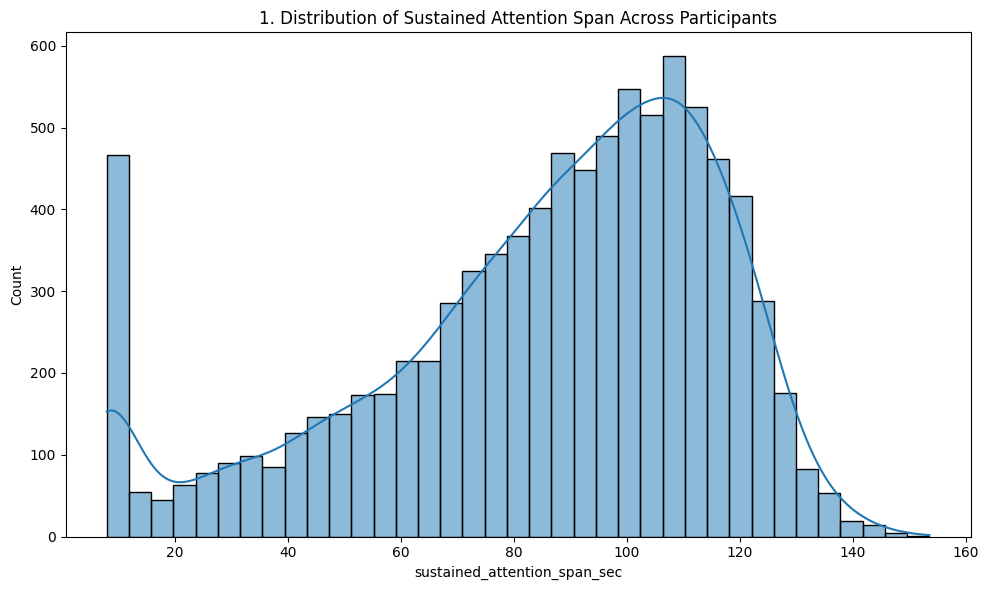

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='sustained_attention_span_sec', kde=True)
plt.title(f'{plot_no}. Distribution of Sustained Attention Span Across Participants')
show_fig()
plot_no += 1

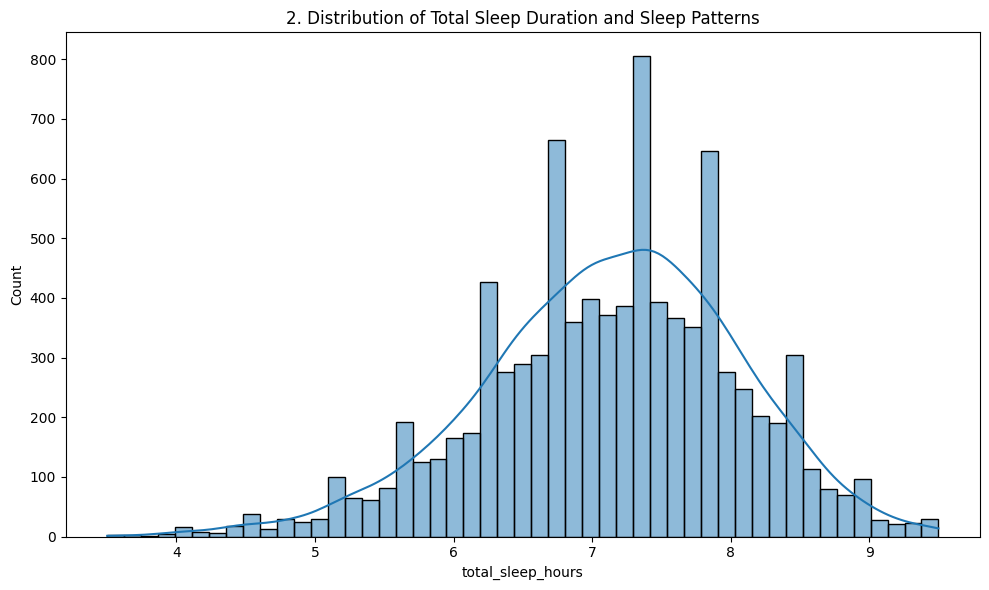

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='total_sleep_hours', kde=True)
plt.title(f'{plot_no}. Distribution of Total Sleep Duration and Sleep Patterns')
show_fig()
plot_no += 1

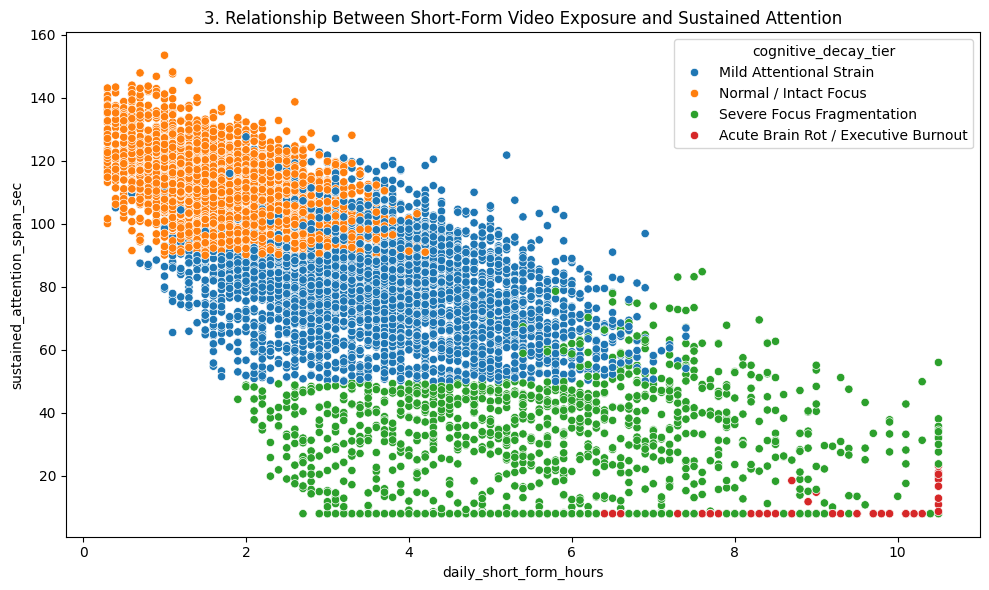

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='daily_short_form_hours', y='sustained_attention_span_sec', hue='cognitive_decay_tier')
plt.title(f'{plot_no}. Relationship Between Short-Form Video Exposure and Sustained Attention')
show_fig()
plot_no += 1

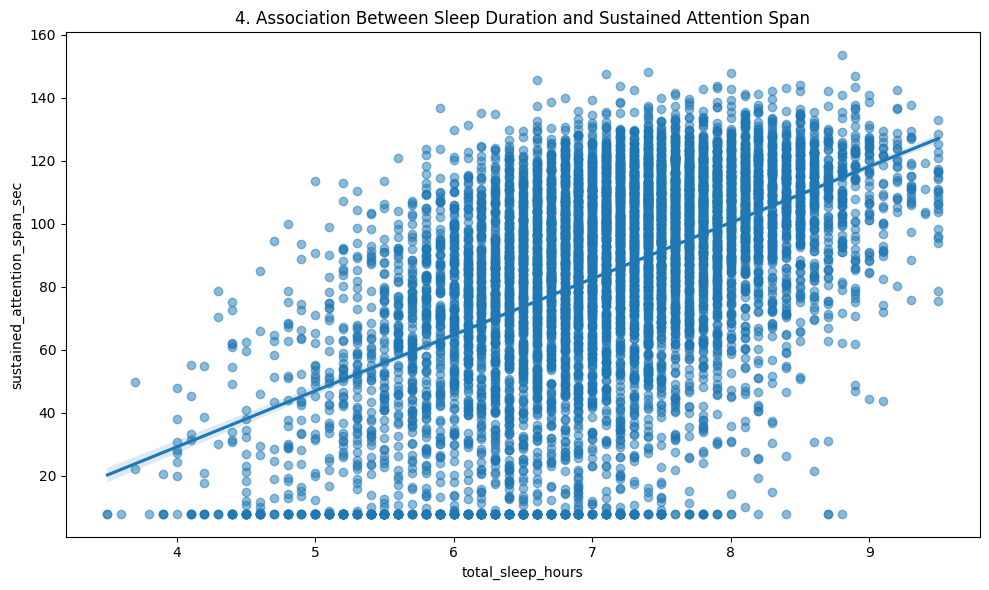

In [16]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='total_sleep_hours', y='sustained_attention_span_sec', scatter_kws={'alpha':0.5})
plt.title(f'{plot_no}. Association Between Sleep Duration and Sustained Attention Span')
show_fig()
plot_no += 1

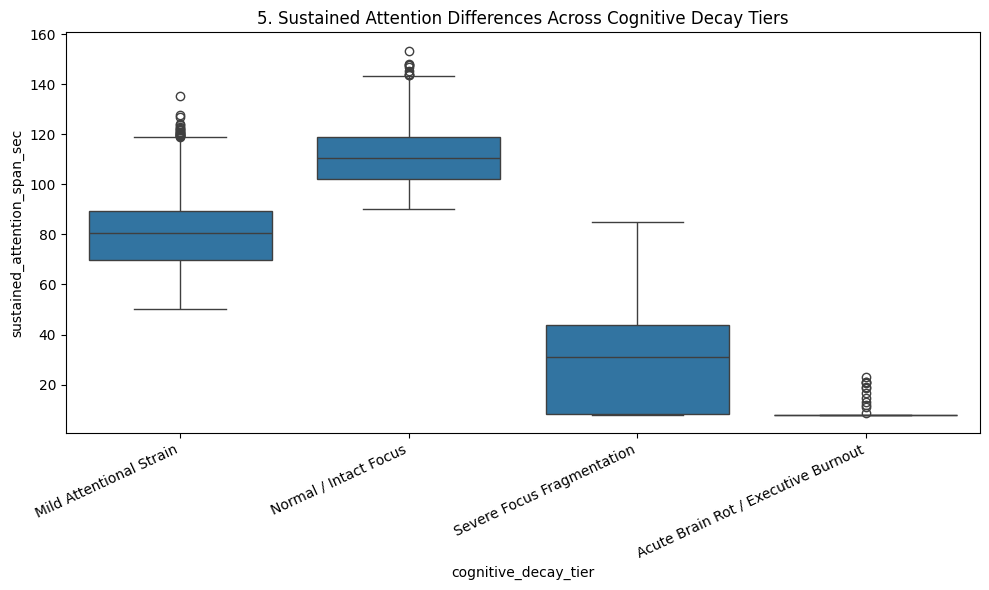

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='cognitive_decay_tier', y='sustained_attention_span_sec')
plt.xticks(rotation=25, ha='right')
plt.title(f'{plot_no}. Sustained Attention Differences Across Cognitive Decay Tiers')
show_fig()
plot_no += 1

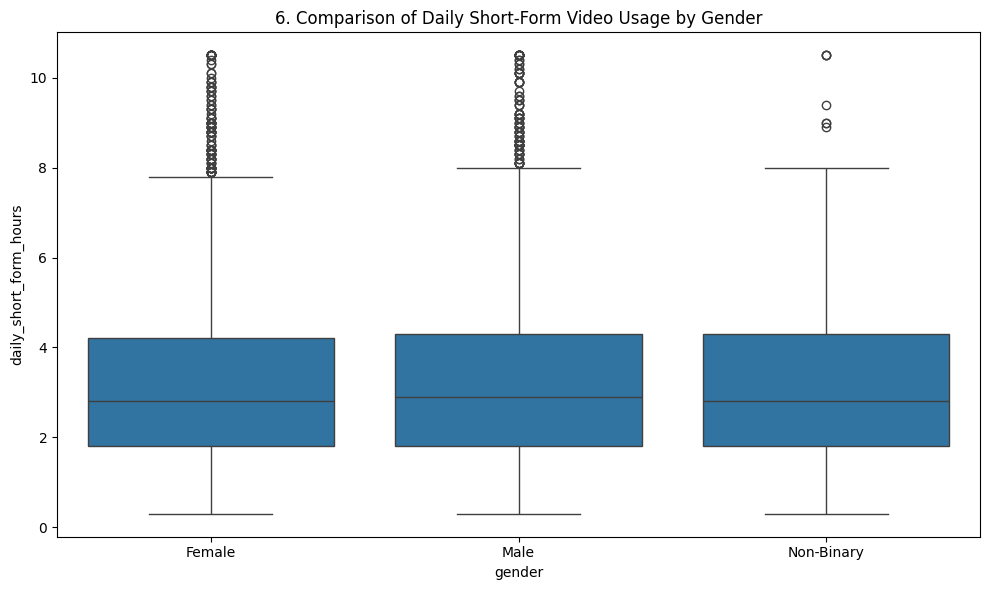

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='gender', y='daily_short_form_hours')
plt.title(f'{plot_no}. Comparison of Daily Short-Form Video Usage by Gender')
show_fig()
plot_no += 1

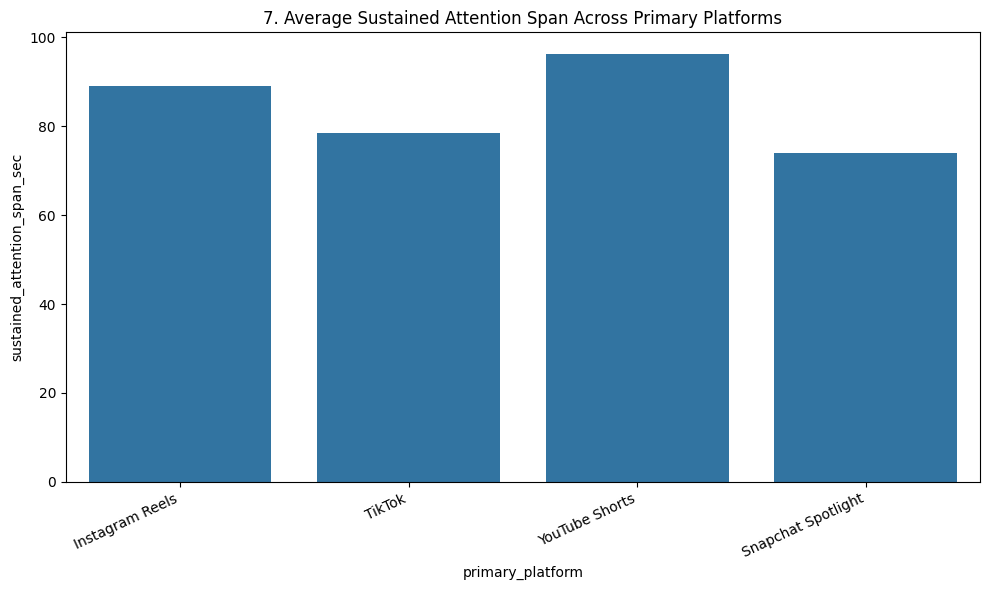

In [19]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='primary_platform', y='sustained_attention_span_sec', errorbar=None)
plt.xticks(rotation=25, ha='right')
plt.title(f'{plot_no}. Average Sustained Attention Span Across Primary Platforms')
show_fig()
plot_no += 1

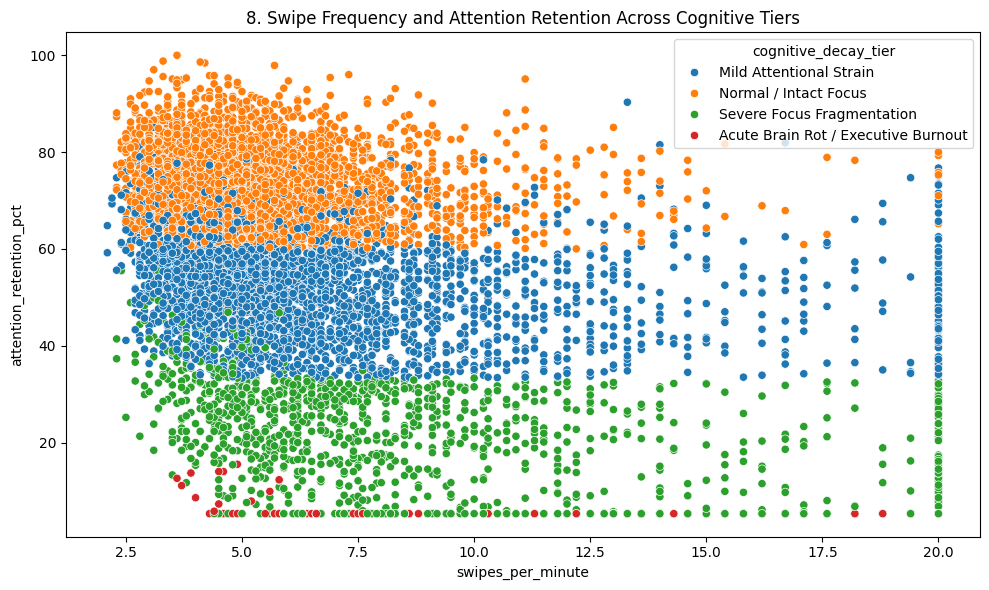

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='swipes_per_minute', y='attention_retention_pct', hue='cognitive_decay_tier')
plt.title(f'{plot_no}. Swipe Frequency and Attention Retention Across Cognitive Tiers')
show_fig()
plot_no += 1

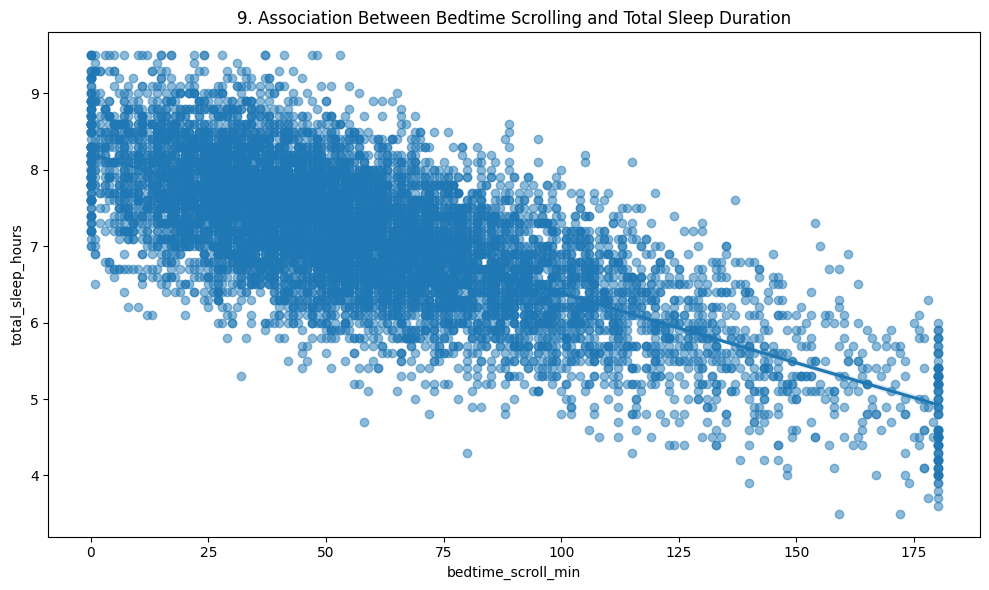

In [21]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='bedtime_scroll_min', y='total_sleep_hours', scatter_kws={'alpha':0.5})
plt.title(f'{plot_no}. Association Between Bedtime Scrolling and Total Sleep Duration')
show_fig()
plot_no += 1

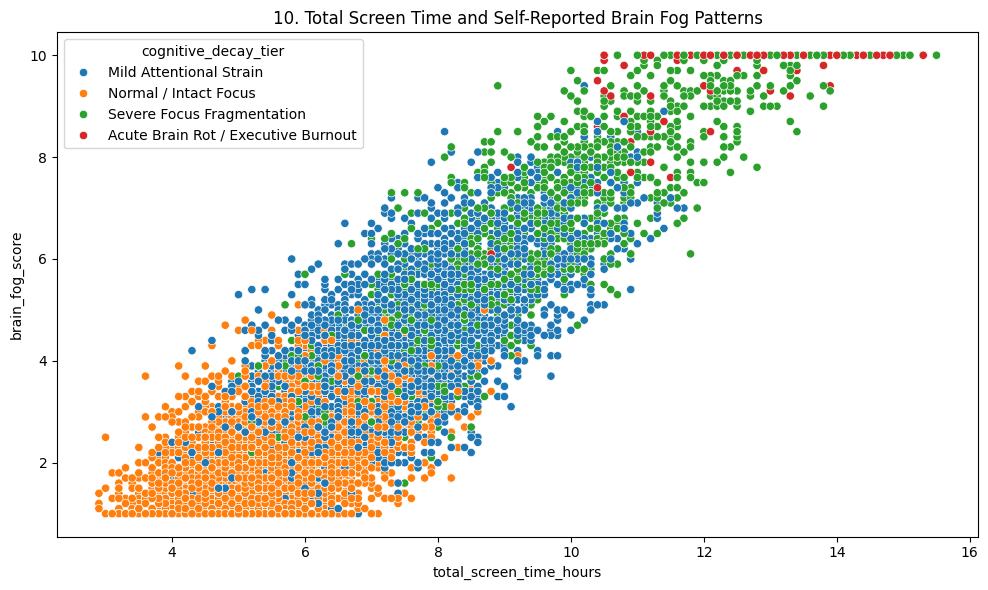

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='total_screen_time_hours', y='brain_fog_score', hue='cognitive_decay_tier')
plt.title(f'{plot_no}. Total Screen Time and Self-Reported Brain Fog Patterns')
show_fig()
plot_no += 1

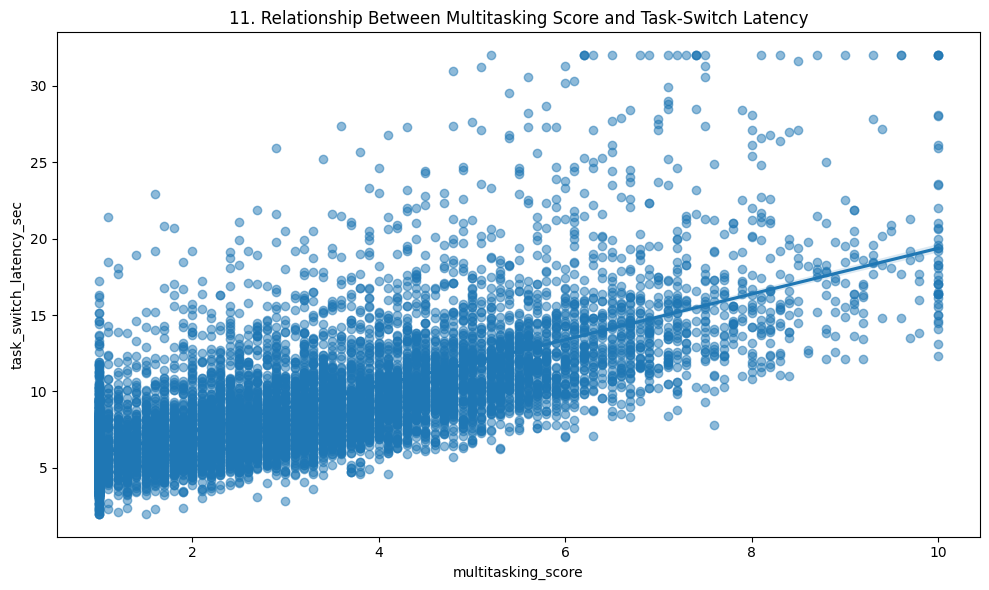

In [23]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='multitasking_score', y='task_switch_latency_sec', scatter_kws={'alpha':0.5})
plt.title(f'{plot_no}. Relationship Between Multitasking Score and Task-Switch Latency')
show_fig()
plot_no += 1

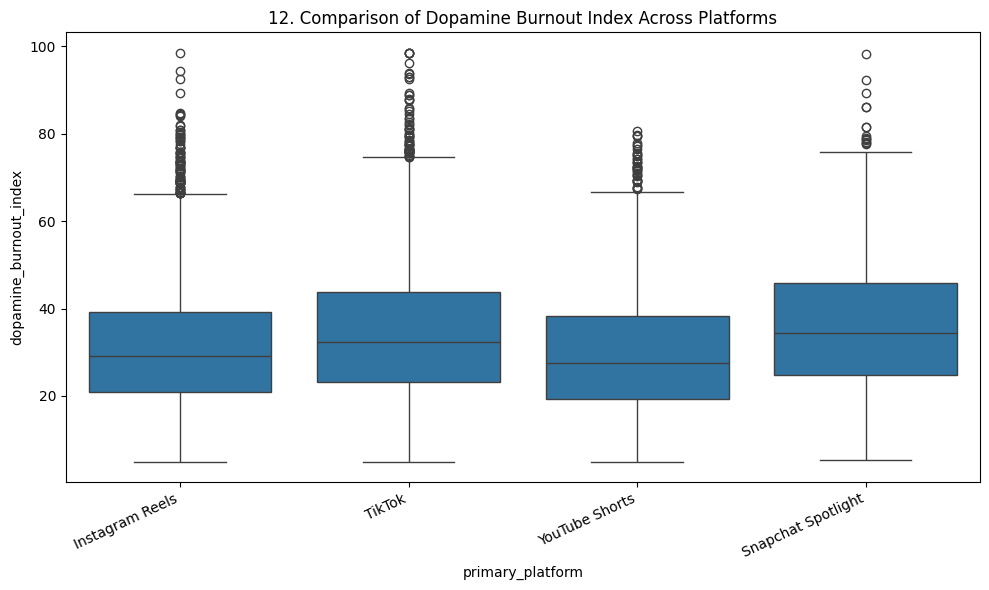

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='primary_platform', y='dopamine_burnout_index')
plt.xticks(rotation=25, ha='right')
plt.title(f'{plot_no}. Comparison of Dopamine Burnout Index Across Platforms')
show_fig()
plot_no += 1

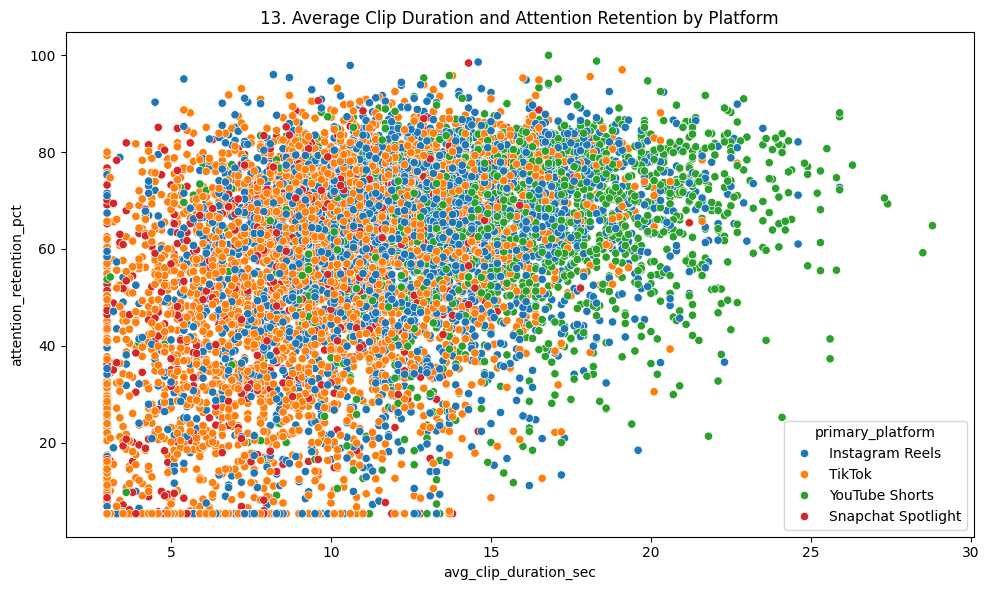

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='avg_clip_duration_sec', y='attention_retention_pct', hue='primary_platform')
plt.title(f'{plot_no}. Average Clip Duration and Attention Retention by Platform')
show_fig()
plot_no += 1

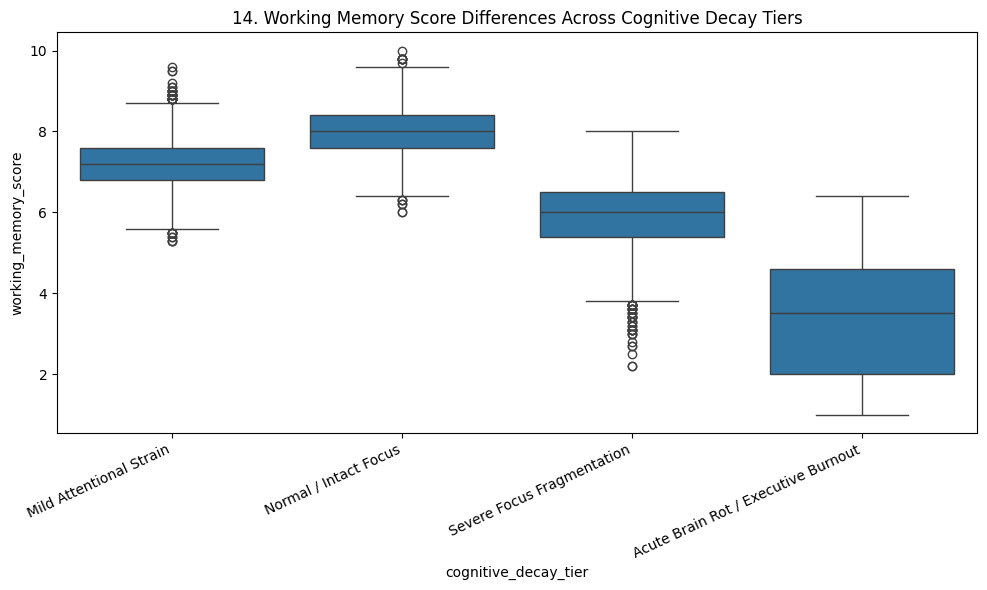

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='cognitive_decay_tier', y='working_memory_score')
plt.xticks(rotation=25, ha='right')
plt.title(f'{plot_no}. Working Memory Score Differences Across Cognitive Decay Tiers')
show_fig()
plot_no += 1

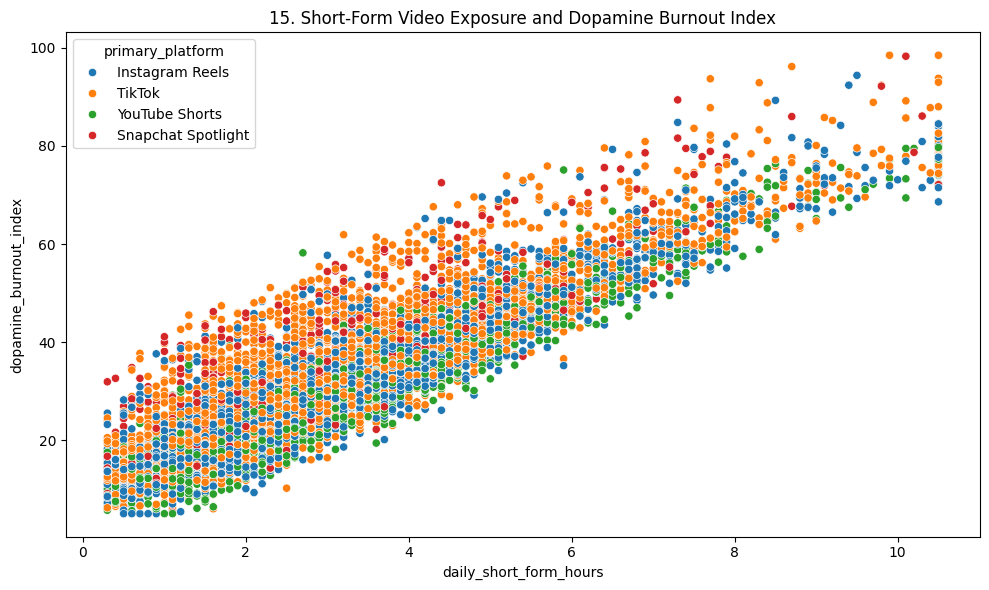

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='daily_short_form_hours', y='dopamine_burnout_index', hue='primary_platform')
plt.title(f'{plot_no}. Short-Form Video Exposure and Dopamine Burnout Index')
show_fig()
plot_no += 1

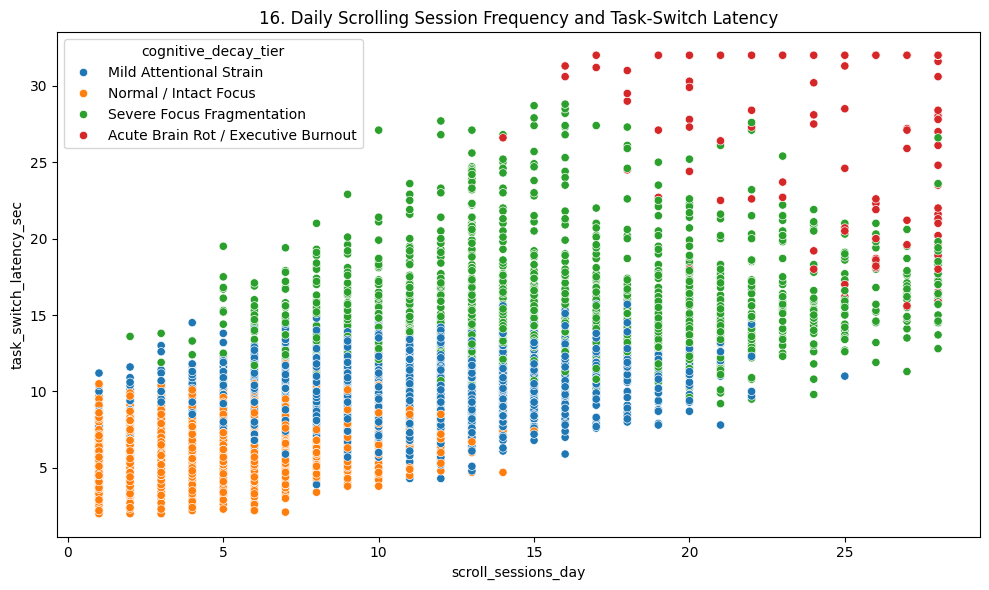

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='scroll_sessions_day', y='task_switch_latency_sec', hue='cognitive_decay_tier')
plt.title(f'{plot_no}. Daily Scrolling Session Frequency and Task-Switch Latency')
show_fig()
plot_no += 1

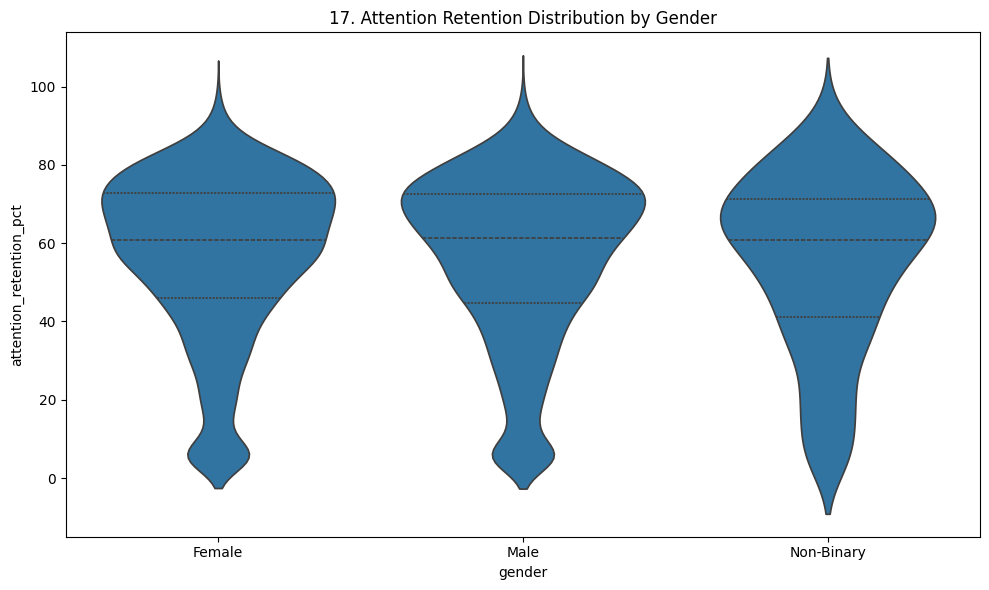

In [29]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='gender', y='attention_retention_pct', inner='quartile')
plt.title(f'{plot_no}. Attention Retention Distribution by Gender')
show_fig()
plot_no += 1

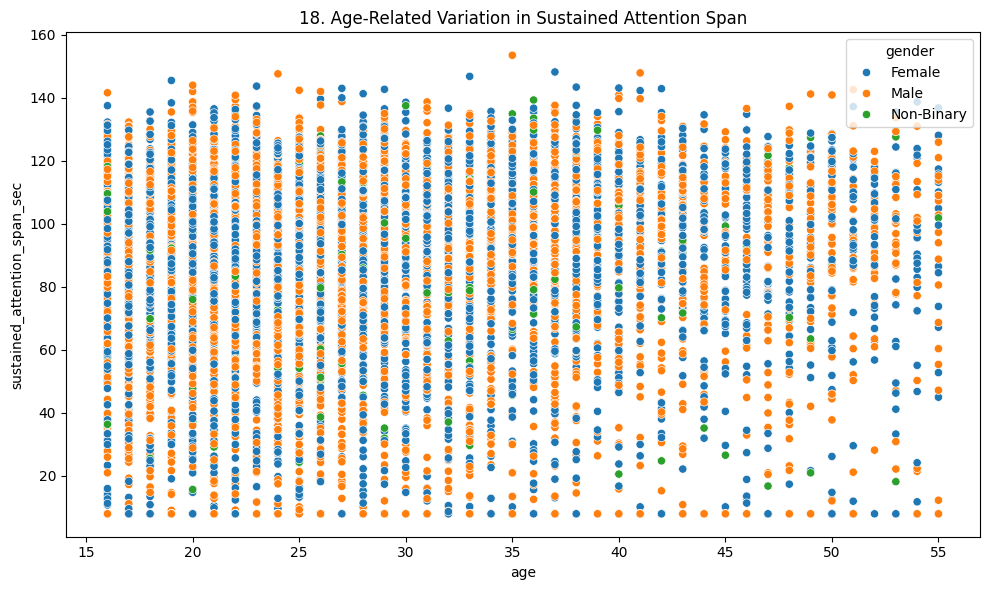

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='sustained_attention_span_sec', hue='gender')
plt.title(f'{plot_no}. Age-Related Variation in Sustained Attention Span')
show_fig()
plot_no += 1

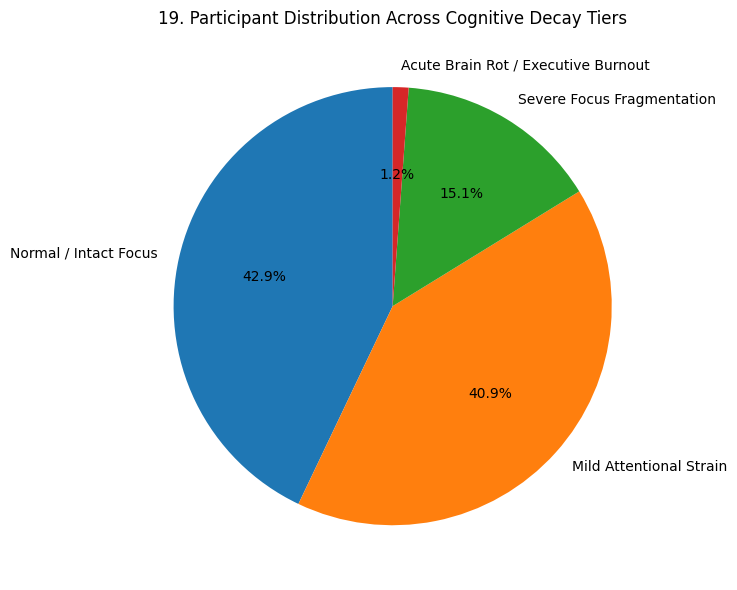

In [31]:
fig = plt.figure(figsize=(10,6))
tier_counts = df['cognitive_decay_tier'].value_counts()
plt.pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', startangle=90)
plt.title(f'{plot_no}. Participant Distribution Across Cognitive Decay Tiers')
show_fig()
plot_no += 1

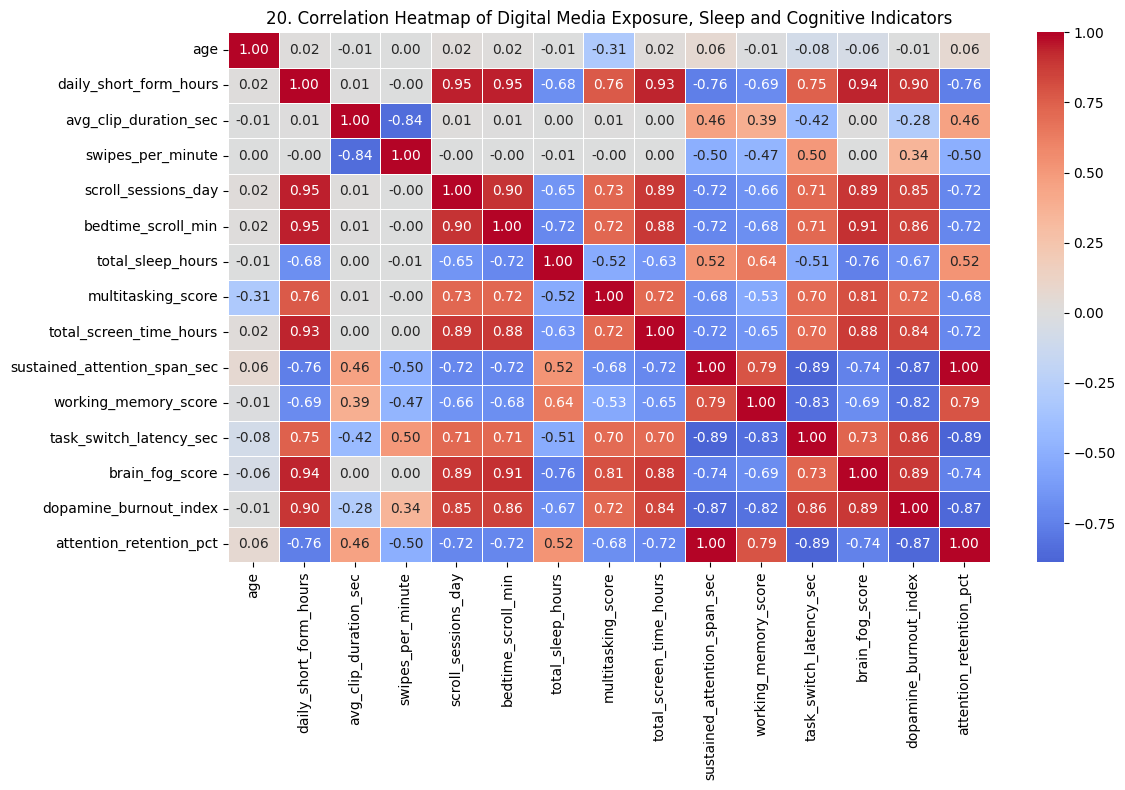

In [32]:
fig = plt.figure(figsize=(12,8))
corr = df.select_dtypes(include='number').drop(columns=['participant_id'], errors='ignore').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, center=0)
plt.title(f'{plot_no}. Correlation Heatmap of Digital Media Exposure, Sleep and Cognitive Indicators')
show_fig()
plot_no += 1

# Model Training

## Select the target and remove identifier and leakage columns

In [33]:
target = 'sustained_attention_span_sec'
drop_cols = ['participant_id', 'attention_retention_pct', 'cognitive_decay_tier']
X = df.drop(columns=[target] + [c for c in drop_cols if c in df.columns], errors='ignore')
y = df[target]

## Encode categorical features and handle missing values

In [34]:
X = pd.get_dummies(X, drop_first=True, dtype=int)
valid = y.notna()
X = X.loc[valid]
y = y.loc[valid]
X = X.replace([np.inf, -np.inf], np.nan)

## Split the dataset into training and testing sets

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Build a scaled gradient boosting regression pipeline

In [36]:
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median', keep_empty_features=True)),
    ('scaler', StandardScaler()),
    ('regressor', HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.05, max_leaf_nodes=15, l2_regularization=1.0,
        random_state=42
    ))
])

## Train the model

In [37]:
model.fit(X_train, y_train)

Pipeline(steps=[('imputer',
                 SimpleImputer(keep_empty_features=True, strategy='median')),
                ('scaler', StandardScaler()),
                ('regressor',
                 HistGradientBoostingRegressor(l2_regularization=1.0,
                                               learning_rate=0.05, max_iter=200,
                                               max_leaf_nodes=15,
                                               random_state=42))])

## Predict attention span on unseen test data

In [38]:
y_pred = model.predict(X_test)

## Print regression accuracy metrics

In [39]:
print(f'R² Score: {r2_score(y_test, y_pred):.4f}')
print(f'Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.4f}')
print(f'Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')

R² Score: 0.9209
Mean Absolute Error: 7.1022
Root Mean Squared Error: 9.0396


## Plot actual versus predicted attention span

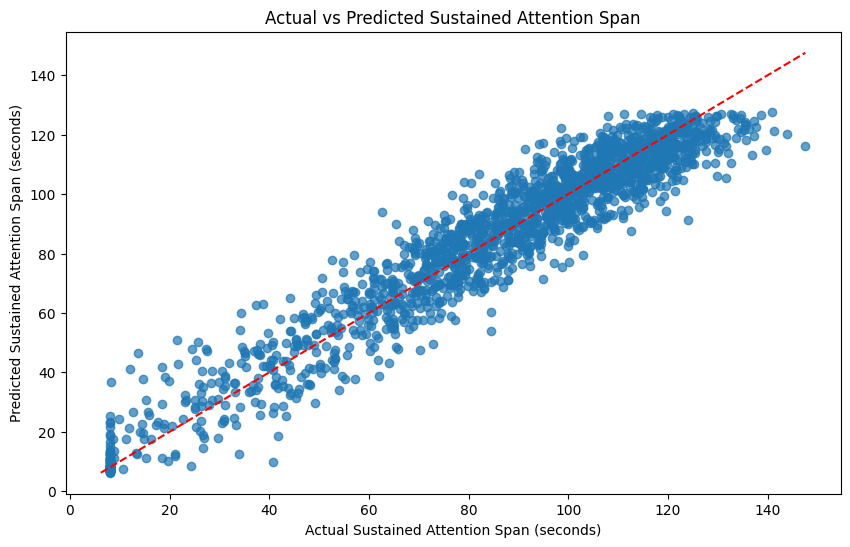

In [40]:
fig = plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())
plt.plot([low, high], [low, high], 'r--')
plt.xlabel('Actual Sustained Attention Span (seconds)')
plt.ylabel('Predicted Sustained Attention Span (seconds)')
plt.title('Actual vs Predicted Sustained Attention Span')
plt.show()